Código Python para o propagador fracionário
Versão 1

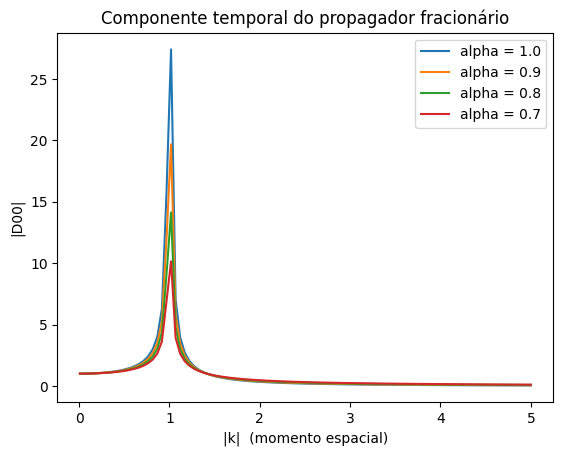

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MÉTRICA DE MINKOWSKI
# (+,-,-,-)
# ------------------------------------------------------------

eta = np.diag([1, -1, -1, -1])


# ------------------------------------------------------------
# FUNÇÃO: calcula k^2 = k_mu eta^{mu nu} k_nu
# ------------------------------------------------------------
def minkowski_k2(k):

    """
    Calcula o escalar relativístico k^2 usando a métrica de Minkowski.

    Parâmetro
    ----------
    k : array
        vetor de momento 4D (k0, kx, ky, kz)

    Retorno
    -------
    escalar k^2
    """

    return k @ eta @ k


# ------------------------------------------------------------
# PROPAGADOR DO FÓTON FRACIONÁRIO
# ------------------------------------------------------------
def photon_propagator_fractional(k, alpha=1.0, xi=1.0):

    """
    Calcula o propagador do fóton fracionário no espaço de momento.

    A expressão usada é

    D_{μν}(k) = -i/(k²)^α [ η_{μν} - (1-ξ)/(k²)^α k_μ k_ν ]

    Parâmetros
    ----------
    k : vetor de momento 4D
    alpha : parâmetro fracionário
    xi : parâmetro de gauge

    Retorno
    -------
    matriz 4x4 correspondente ao propagador
    """

    k = np.array(k)

    # calcula k^2
    k2 = minkowski_k2(k)

    # prefator global do propagador
    prefactor = -1j / (np.abs(k2)**alpha + 1e-8)

    # primeiro termo: métrica
    term1 = eta

    # segundo termo: parte longitudinal
    term2 = ((1 - xi) / (np.abs(k2)**alpha + 1e-8)) * np.outer(k, k)

    # matriz final do propagador
    D = prefactor * (term1 - term2)

    return D


# ------------------------------------------------------------
# ESTUDO NUMÉRICO DO PROPAGADOR
# ------------------------------------------------------------

# valores do momento espacial
k_values = np.linspace(0.01, 5, 100)

# diferentes valores do parâmetro fracionário
alpha_values = [1.0, 0.9, 0.8, 0.7]

plt.figure()

for alpha in alpha_values:

    D00 = []

    for k in k_values:

        # vetor de momento com componente espacial
        vec = np.array([1.0, k, 0, 0])

        # calcula o propagador
        D = photon_propagator_fractional(vec, alpha, xi=1)

        # guardamos |D00| (magnitude)
        D00.append(np.abs(D[0,0]))

    plt.plot(k_values, D00, label=f'alpha = {alpha}')

plt.xlabel("|k|  (momento espacial)")
plt.ylabel("|D00|")
plt.title("Componente temporal do propagador fracionário")
plt.legend()

plt.show()

versão 2

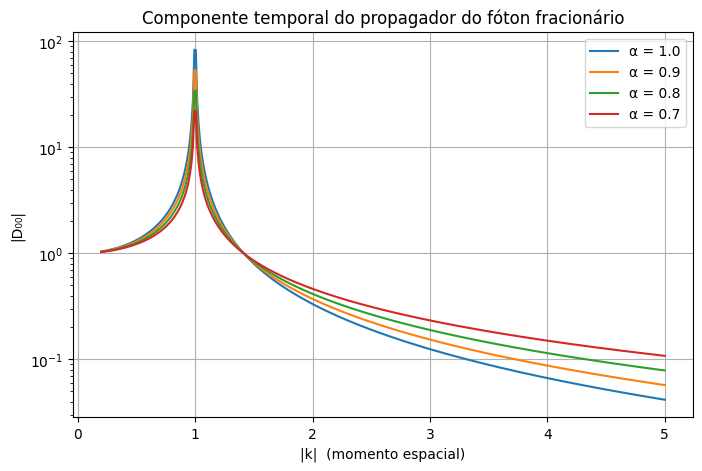

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# MÉTRICA DE MINKOWSKI
# (+,-,-,-)
# ==========================================================

eta = np.diag([1, -1, -1, -1])


# ==========================================================
# FUNÇÃO: calcula k^2 = k_mu eta^{mu nu} k_nu
# ==========================================================

def minkowski_k2(k):
    """
    Calcula o escalar relativístico k^2 usando a métrica de Minkowski.

    Parâmetro
    ----------
    k : vetor 4D (k0, kx, ky, kz)

    Retorna
    ----------
    valor escalar k^2
    """

    return k @ eta @ k


# ==========================================================
# PROPAGADOR DO FÓTON FRACIONÁRIO
# ==========================================================

def photon_propagator_fractional(k, alpha=1.0, xi=1.0):

    """
    Calcula o propagador do fóton fracionário no espaço de momento.

    Fórmula utilizada:

    D_{μν}(k) = -i/(k²)^α [ η_{μν} - (1-ξ)/(k²)^α k_μ k_ν ]

    Parâmetros
    ----------
    k : vetor de momento 4D
    alpha : parâmetro fracionário
    xi : parâmetro de gauge

    Retorna
    ----------
    matriz 4x4 do propagador
    """

    k = np.array(k)

    # calcula k^2
    k2 = minkowski_k2(k)

    # --------------------------------------------------
    # Correção numérica
    # usamos |k^2| para evitar potência fracionária
    # de número negativo e adicionamos epsilon
    # para evitar divisão por zero
    # --------------------------------------------------

    eps = 1e-8
    k2_eff = np.abs(k2) + eps

    # prefator global
    prefactor = -1j / (k2_eff ** alpha)

    # termo proporcional à métrica
    term1 = eta

    # termo longitudinal
    term2 = ((1 - xi) / (k2_eff ** alpha)) * np.outer(k, k)

    # matriz final do propagador
    D = prefactor * (term1 - term2)

    return D


# ==========================================================
# ESTUDO NUMÉRICO DO PROPAGADOR
# ==========================================================

# valores do momento espacial
k_values = np.linspace(0.2, 5, 400)

# valores do parâmetro fracionário
alpha_values = [1.0, 0.9, 0.8, 0.7]

plt.figure(figsize=(8,5))

for alpha in alpha_values:

    D00_vals = []

    for k in k_values:

        # vetor de momento escolhido
        # k = (energia, momento espacial, 0, 0)
        vec = np.array([1.0, k, 0, 0])

        # calcula o propagador
        D = photon_propagator_fractional(vec, alpha, xi=1)

        # usamos o módulo para visualizar melhor
        D00_vals.append(np.abs(D[0,0]))

    plt.plot(k_values, D00_vals, label=f'α = {alpha}')

plt.xlabel("|k|  (momento espacial)")
plt.ylabel("|D₀₀|")
plt.title("Componente temporal do propagador do fóton fracionário")
plt.yscale("log")   # escala log melhora muito a visualização
plt.legend()
plt.grid(True)

plt.show()

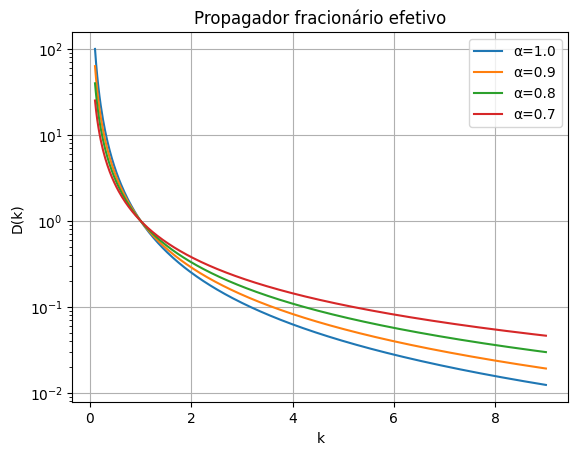

In [14]:
import numpy as np
import matplotlib.pyplot as plt

k = np.linspace(0.1,9,400)

alphas = [1.0,0.9,0.8,0.7]

plt.figure()

for a in alphas:

    D = 1/(k**(2*a))

    plt.plot(k,D,label=f'α={a}')

plt.yscale("log")

plt.xlabel("k")
plt.ylabel("D(k)")
plt.title("Propagador fracionário efetivo")

plt.legend()
plt.grid()

plt.show()